In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/processed/cleaned_inventory.csv")

df["Date"] = pd.to_datetime(df["Date"])

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (16740, 14)


,Date,Product_ID,Product_Name,Category,Brand,Current_Stock,Units_Sold,Unit_Price,Discount_Percent,Promotion,Holiday,Lead_Time_Days,Safety_Stock,Stockout
0,2022-02-17,P001,iPhone 13,Mobile,Apple,154.0,9,65000.0,0.0,0,0,7.0,15,0
1,2026-06-06,P008,Samsung 55-inch Smart TV,TV,Samsung,101.0,3,120000.0,0.0,1,0,14.0,5,0
2,2025-06-04,P006,HP Pavilion 15,Laptop,HP,101.0,5,95000.0,0.0,1,0,9.0,8,0
3,2022-11-14,P004,Redmi Note 13,Mobile,Xiaomi,91.0,10,32000.0,0.0,0,0,5.0,20,0
4,2025-08-08,P001,iPhone 13,Mobile,Apple,129.0,5,65000.0,0.0,0,0,7.0,15,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16740 entries, 0 to 16739
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              16740 non-null  datetime64[ns]
 1   Product_ID        16740 non-null  object        
 2   Product_Name      16740 non-null  object        
 3   Category          16740 non-null  object        
 4   Brand             16740 non-null  object        
 5   Current_Stock     16740 non-null  float64       
 6   Units_Sold        16740 non-null  int64         
 7   Unit_Price        16740 non-null  float64       
 8   Discount_Percent  16740 non-null  float64       
 9   Promotion         16740 non-null  int64         
 10  Holiday           16740 non-null  int64         
 11  Lead_Time_Days    16740 non-null  float64       
 12  Safety_Stock      16740 non-null  int64         
 13  Stockout          16740 non-null  int64         
dtypes: datetime64[ns](1), 

In [4]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,16740,2024-04-16 12:00:00,2022-01-01 00:00:00,2023-02-23 00:00:00,2024-04-16 12:00:00,2025-06-09 00:00:00,2026-08-01 00:00:00,NaN
Current_Stock,16740.0,107.310335,0.0,87.0,106.0,128.0,230.0,31.171042
Units_Sold,16740.0,4.934588,0.0,2.0,4.0,7.0,110.0,3.955389
Unit_Price,16740.0,80500.0,32000.0,65000.0,81500.0,95000.0,120000.0,24837.20699
Discount_Percent,16740.0,0.279869,0.0,0.0,0.0,0.0,20.0,1.93869
Promotion,16740.0,0.15675,0.0,0.0,0.0,0.0,1.0,0.363576
Holiday,16740.0,0.010753,0.0,0.0,0.0,0.0,1.0,0.103139
Lead_Time_Days,16740.0,9.4,5.0,7.0,9.5,12.0,14.0,3.039828
Safety_Stock,16740.0,10.7,5.0,6.0,8.0,15.0,20.0,5.404789
Stockout,16740.0,0.015293,0.0,0.0,0.0,0.0,1.0,0.122718


In [5]:
df.isnull().sum()

Date                0
Product_ID          0
Product_Name        0
Category            0
Brand               0
Current_Stock       0
Units_Sold          0
Unit_Price          0
Discount_Percent    0
Promotion           0
Holiday             0
Lead_Time_Days      0
Safety_Stock        0
Stockout            0
dtype: int64

In [6]:
product_counts = df["Product_Name"].value_counts()

print(product_counts)

Product_Name
iPhone 13                   1674
Samsung 55-inch Smart TV    1674
HP Pavilion 15              1674
Redmi Note 13               1674
iPhone 15                   1674
Samsung Galaxy A55          1674
Dell Inspiron 15            1674
Lenovo IdeaPad 3            1674
Sony 50-inch Bravia TV      1674
LG 43-inch Smart TV         1674
Name: count, dtype: int64


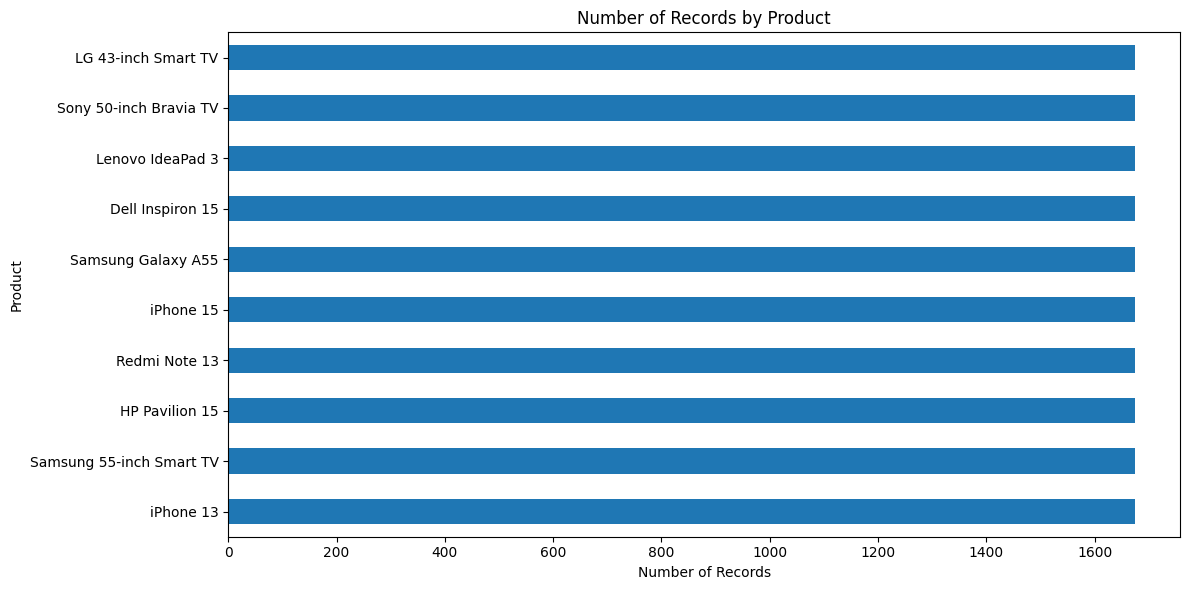

In [7]:
plt.figure(figsize=(12, 6))

product_counts.sort_values().plot(kind="barh")

plt.title("Number of Records by Product")
plt.xlabel("Number of Records")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [8]:
category_counts = df["Category"].value_counts()

print(category_counts)

Category
Mobile    6696
TV        5022
Laptop    5022
Name: count, dtype: int64


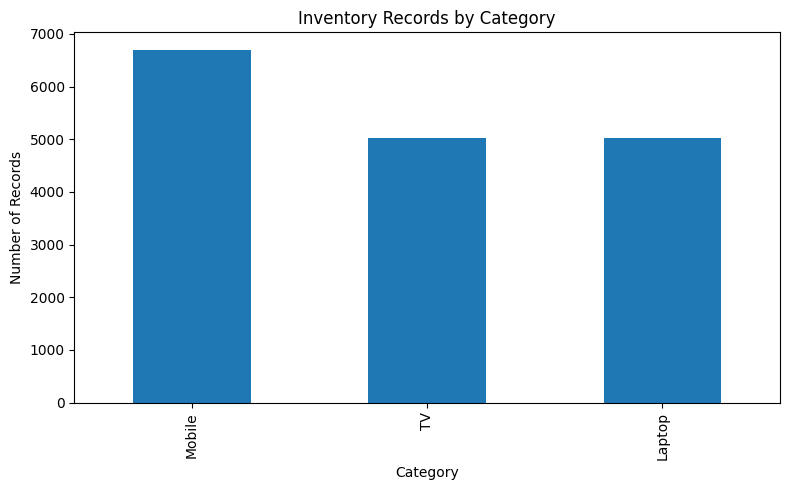

In [9]:
plt.figure(figsize=(8, 5))

category_counts.plot(kind="bar")

plt.title("Inventory Records by Category")
plt.xlabel("Category")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

In [10]:
product_sales = (
    df.groupby("Product_Name")["Units_Sold"]
      .sum()
      .sort_values(ascending=False)
)

print(product_sales)

Product_Name
Samsung Galaxy A55          13990
Redmi Note 13               13978
iPhone 13                   12897
iPhone 15                   11470
HP Pavilion 15               7464
Lenovo IdeaPad 3             5942
Dell Inspiron 15             5331
Samsung 55-inch Smart TV     4459
LG 43-inch Smart TV          4288
Sony 50-inch Bravia TV       2786
Name: Units_Sold, dtype: int64


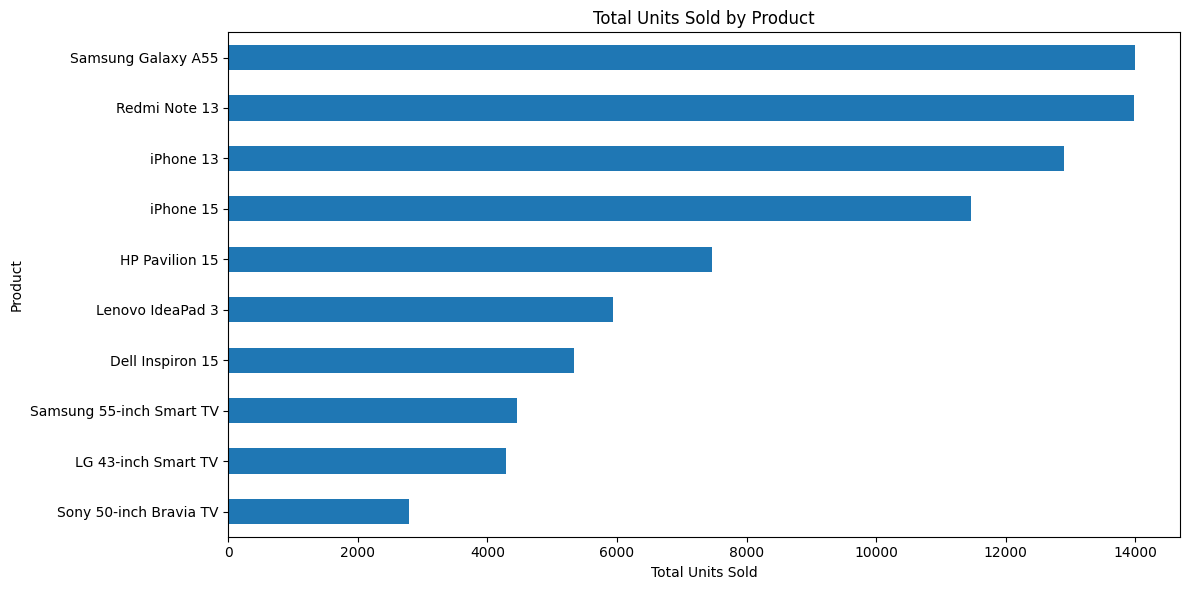

In [11]:
plt.figure(figsize=(12, 6))

product_sales.sort_values().plot(kind="barh")

plt.title("Total Units Sold by Product")
plt.xlabel("Total Units Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [12]:
average_daily_demand = (
    df.groupby("Product_Name")["Units_Sold"]
      .mean()
      .sort_values(ascending=False)
)

print(average_daily_demand)

Product_Name
Samsung Galaxy A55          8.357228
Redmi Note 13               8.350060
iPhone 13                   7.704301
iPhone 15                   6.851852
HP Pavilion 15              4.458781
Lenovo IdeaPad 3            3.549582
Dell Inspiron 15            3.184588
Samsung 55-inch Smart TV    2.663680
LG 43-inch Smart TV         2.561529
Sony 50-inch Bravia TV      1.664277
Name: Units_Sold, dtype: float64


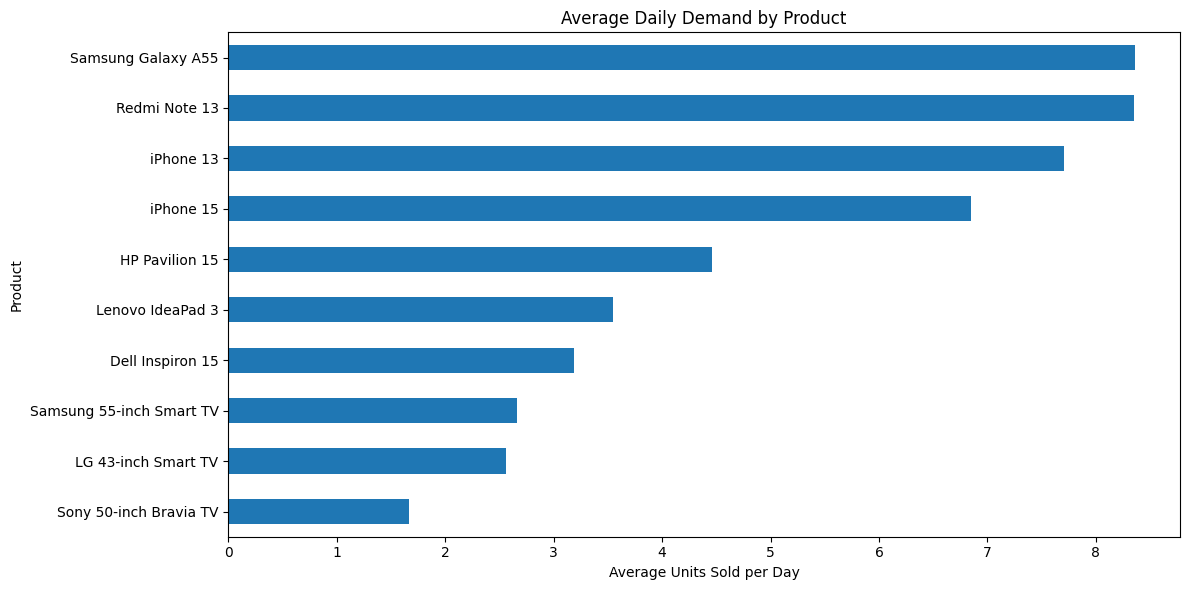

In [13]:
plt.figure(figsize=(12, 6))

average_daily_demand.sort_values().plot(kind="barh")

plt.title("Average Daily Demand by Product")
plt.xlabel("Average Units Sold per Day")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

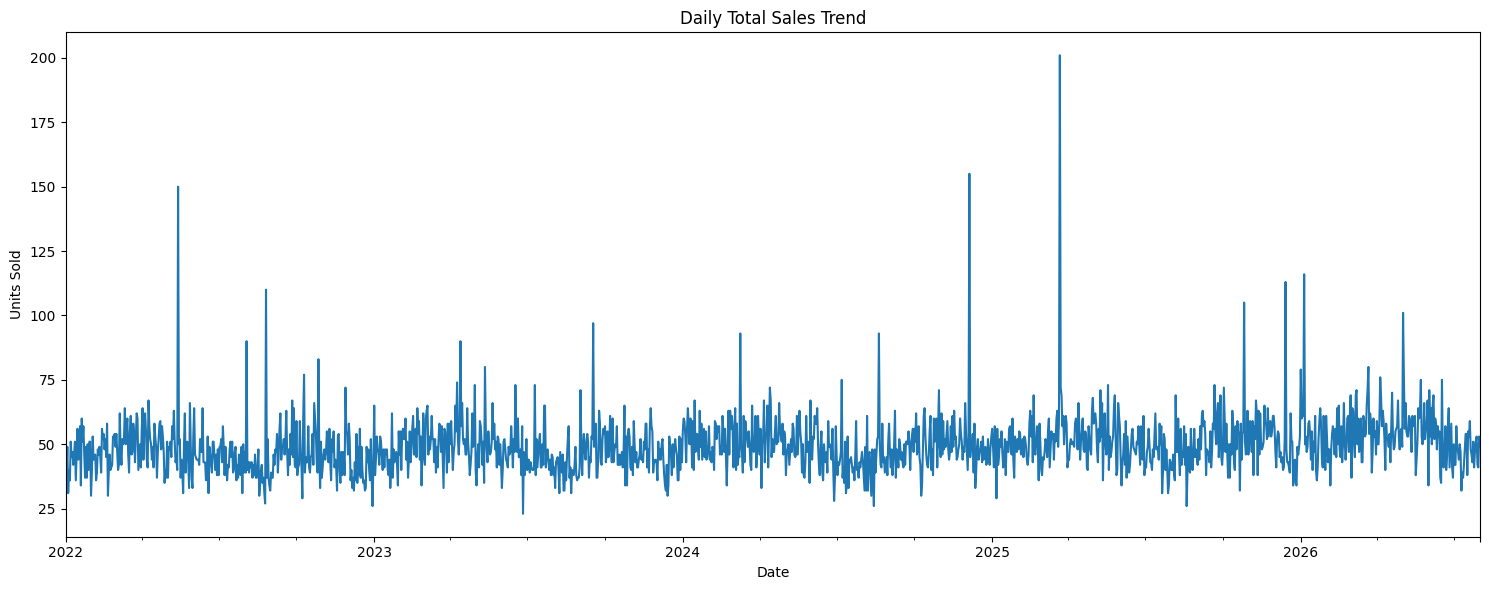

In [14]:
daily_sales = (
    df.groupby("Date")["Units_Sold"]
      .sum()
)

plt.figure(figsize=(15, 6))

daily_sales.plot()

plt.title("Daily Total Sales Trend")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

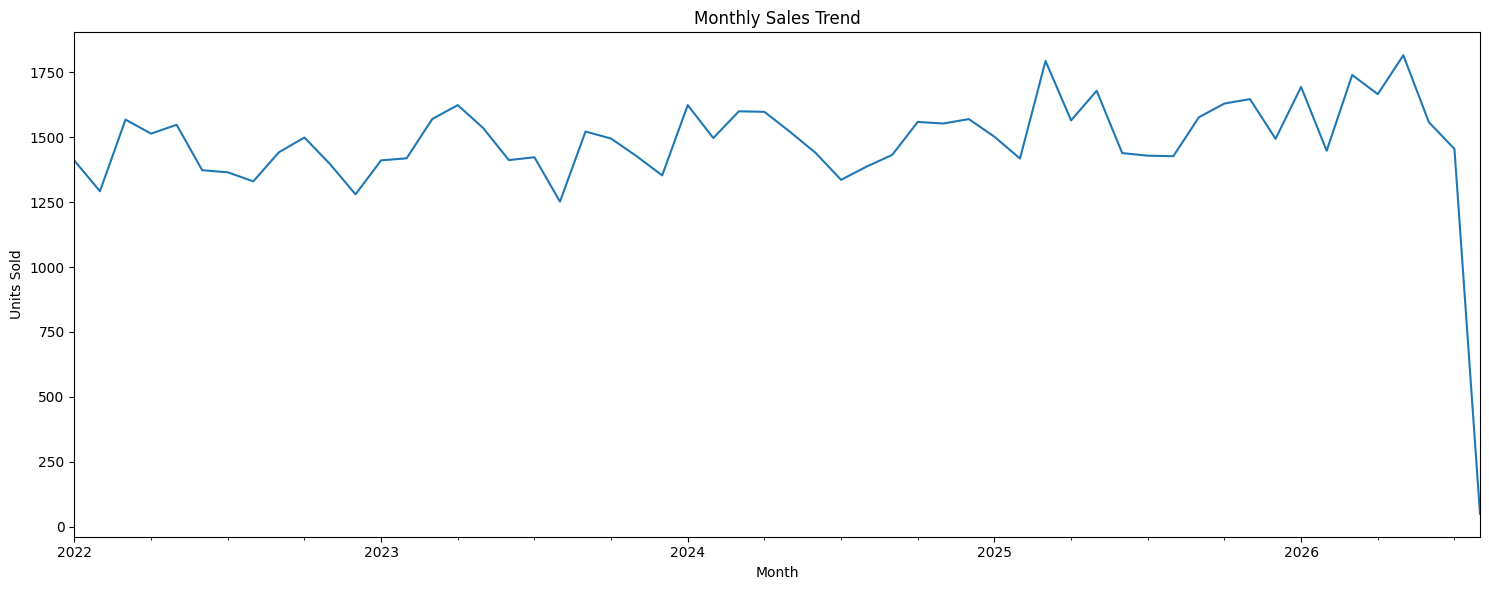

In [15]:
monthly_sales = (
    df.set_index("Date")["Units_Sold"]
      .resample("M")
      .sum()
)

plt.figure(figsize=(15, 6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

In [16]:
monthly_category_sales = (
    df.set_index("Date")
      .groupby("Category")["Units_Sold"]
      .resample("M")
      .sum()
      .unstack(level=0)
)

monthly_category_sales.head()

Category,Laptop,Mobile,TV
Date,,,
2022-01-31,356,846,208
2022-02-28,282,819,191
2022-03-31,348,1027,193
2022-04-30,346,965,203
2022-05-31,332,1040,176


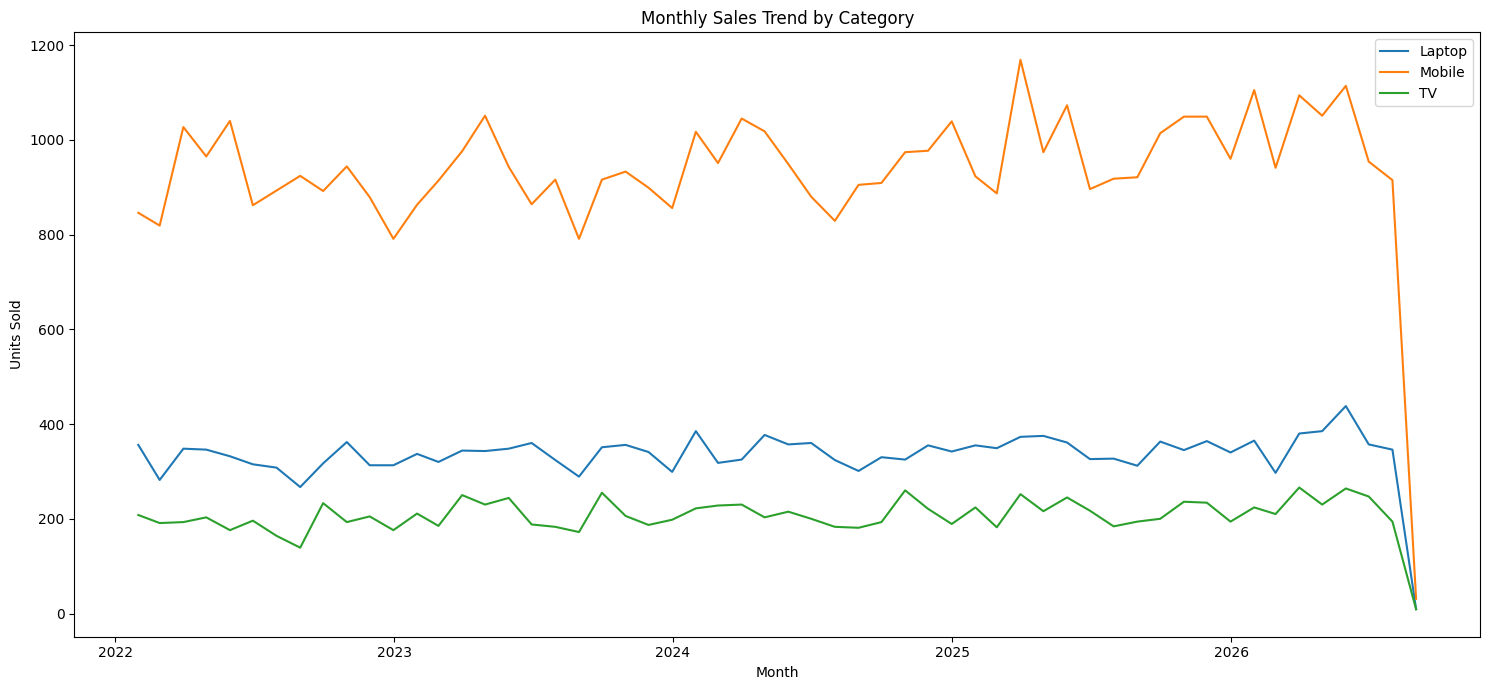

In [17]:
plt.figure(figsize=(15, 7))

for category in monthly_category_sales.columns:
    plt.plot(
        monthly_category_sales.index,
        monthly_category_sales[category],
        label=category
    )

plt.title("Monthly Sales Trend by Category")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.legend()

plt.tight_layout()
plt.show()

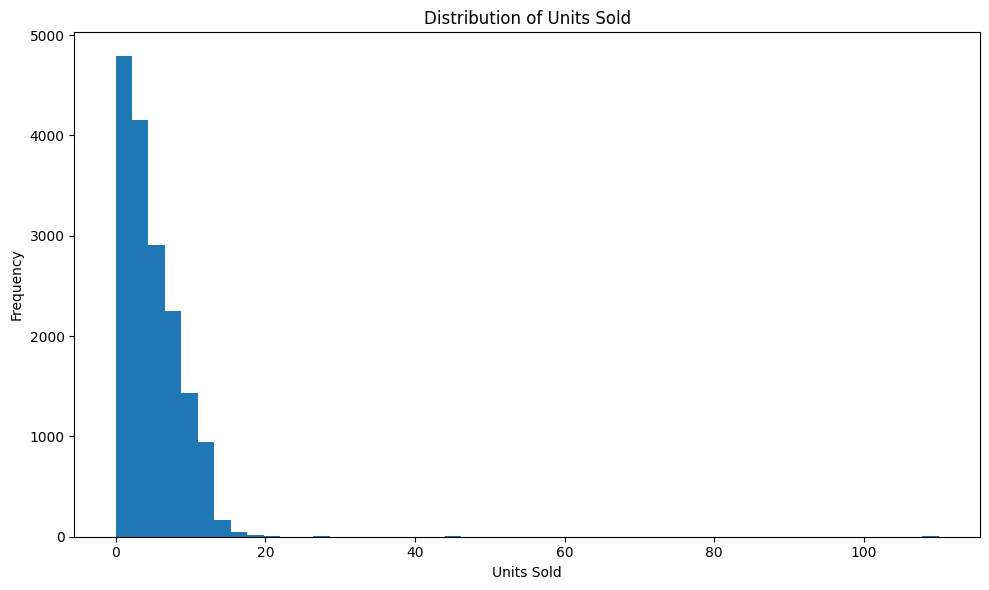

In [18]:
plt.figure(figsize=(10, 6))

plt.hist(df["Units_Sold"], bins=50)

plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

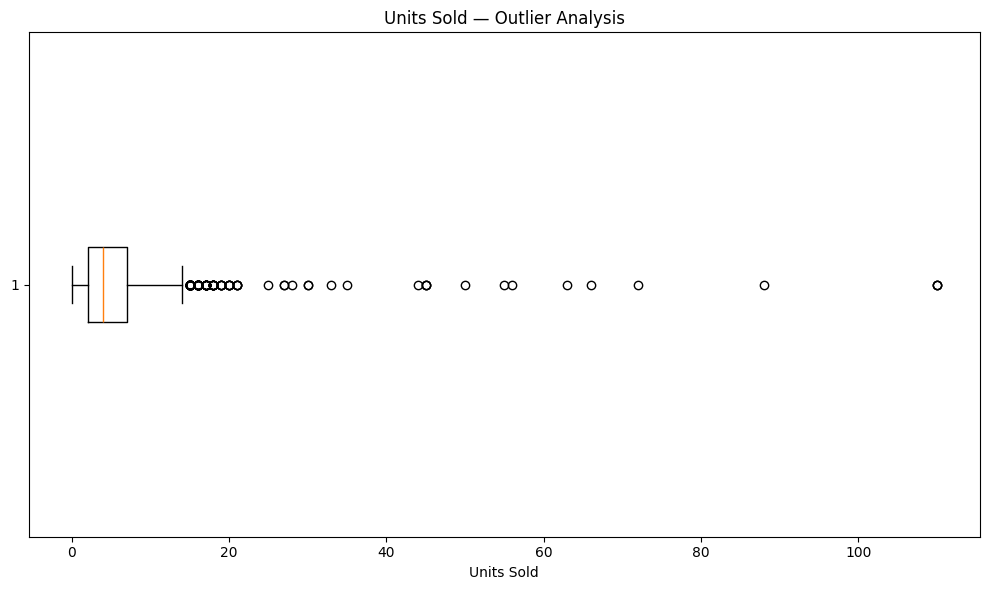

In [19]:
plt.figure(figsize=(10, 6))

plt.boxplot(df["Units_Sold"], vert=False)

plt.title("Units Sold — Outlier Analysis")
plt.xlabel("Units Sold")

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

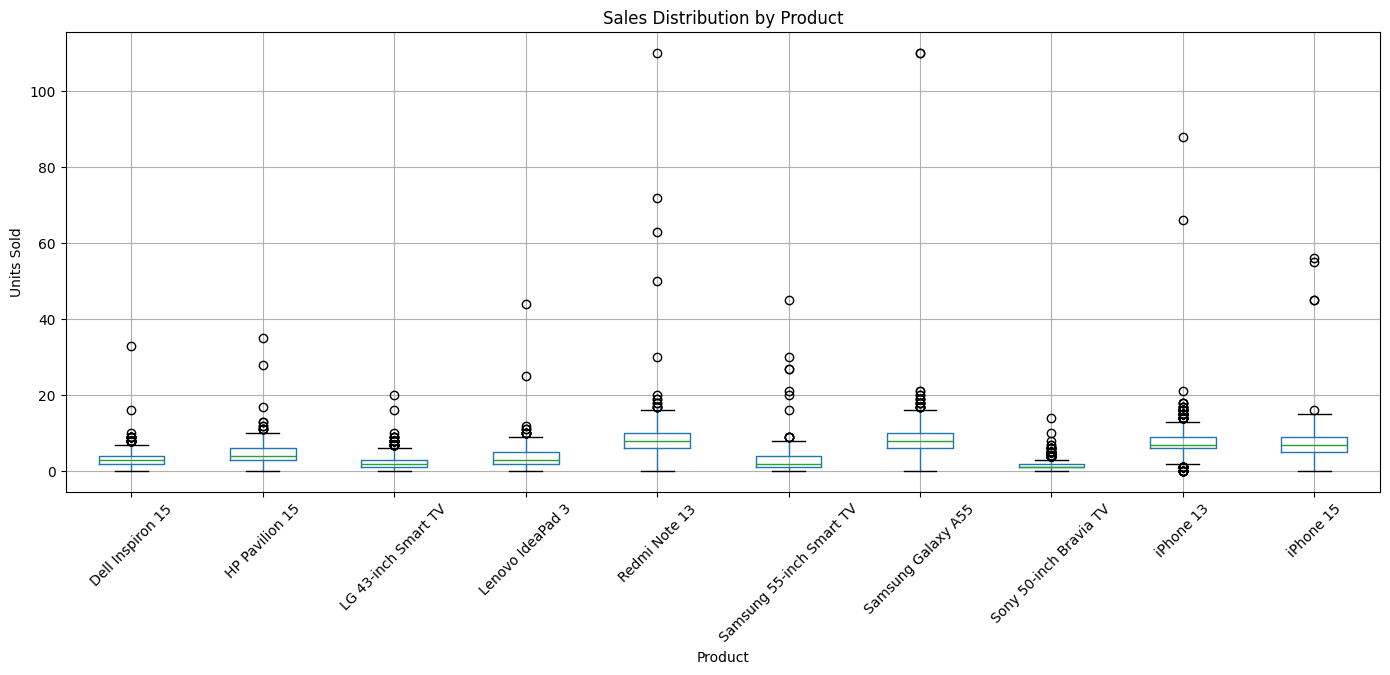

In [20]:
plt.figure(figsize=(12, 6))

df.boxplot(
    column="Units_Sold",
    by="Product_Name",
    figsize=(14, 7)
)

plt.title("Sales Distribution by Product")
plt.suptitle("")
plt.xlabel("Product")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [21]:
promotion_sales = (
    df.groupby("Promotion")["Units_Sold"]
      .agg(["mean", "median", "sum", "count"])
)

promotion_sales

,mean,median,sum,count
Promotion,,,,
0,4.907906,4.0,69280,14116
1,5.078125,4.0,13325,2624


<Figure size 800x500 with 0 Axes>

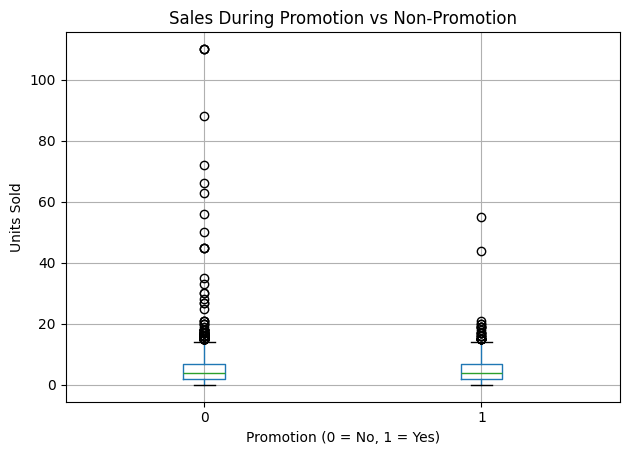

In [22]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="Units_Sold",
    by="Promotion"
)

plt.title("Sales During Promotion vs Non-Promotion")
plt.suptitle("")
plt.xlabel("Promotion (0 = No, 1 = Yes)")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

In [23]:
holiday_sales = (
    df.groupby("Holiday")["Units_Sold"]
      .agg(["mean", "median", "sum", "count"])
)

holiday_sales

,mean,median,sum,count
Holiday,,,,
0,4.923551,4.0,81534,16560
1,5.950000,6.0,1071,180


<Figure size 800x500 with 0 Axes>

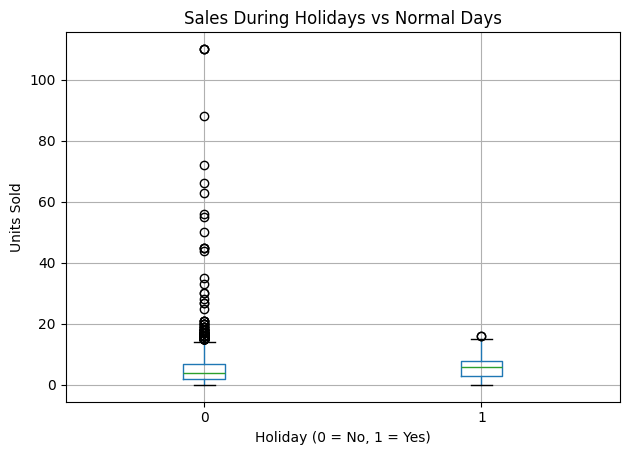

In [24]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="Units_Sold",
    by="Holiday"
)

plt.title("Sales During Holidays vs Normal Days")
plt.suptitle("")
plt.xlabel("Holiday (0 = No, 1 = Yes)")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

In [25]:
stockout_sales = (
    df.groupby("Stockout")["Units_Sold"]
      .agg(["mean", "median", "sum", "count"])
)

stockout_sales

,mean,median,sum,count
Stockout,,,,
0,4.996481,4.0,82362,16484
1,0.949219,1.0,243,256


In [26]:
pd.crosstab(
    df["Stockout"],
    df["Current_Stock"] == 0
)

Current_Stock,False,True
Stockout,,
0,16484,0
1,179,77


<Figure size 800x500 with 0 Axes>

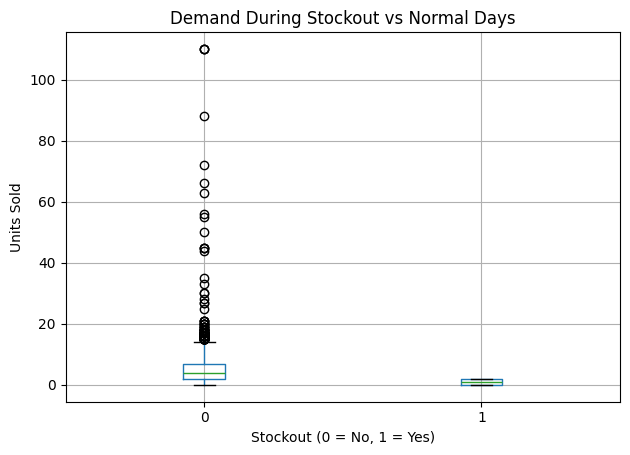

In [27]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="Units_Sold",
    by="Stockout"
)

plt.title("Demand During Stockout vs Normal Days")
plt.suptitle("")
plt.xlabel("Stockout (0 = No, 1 = Yes)")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

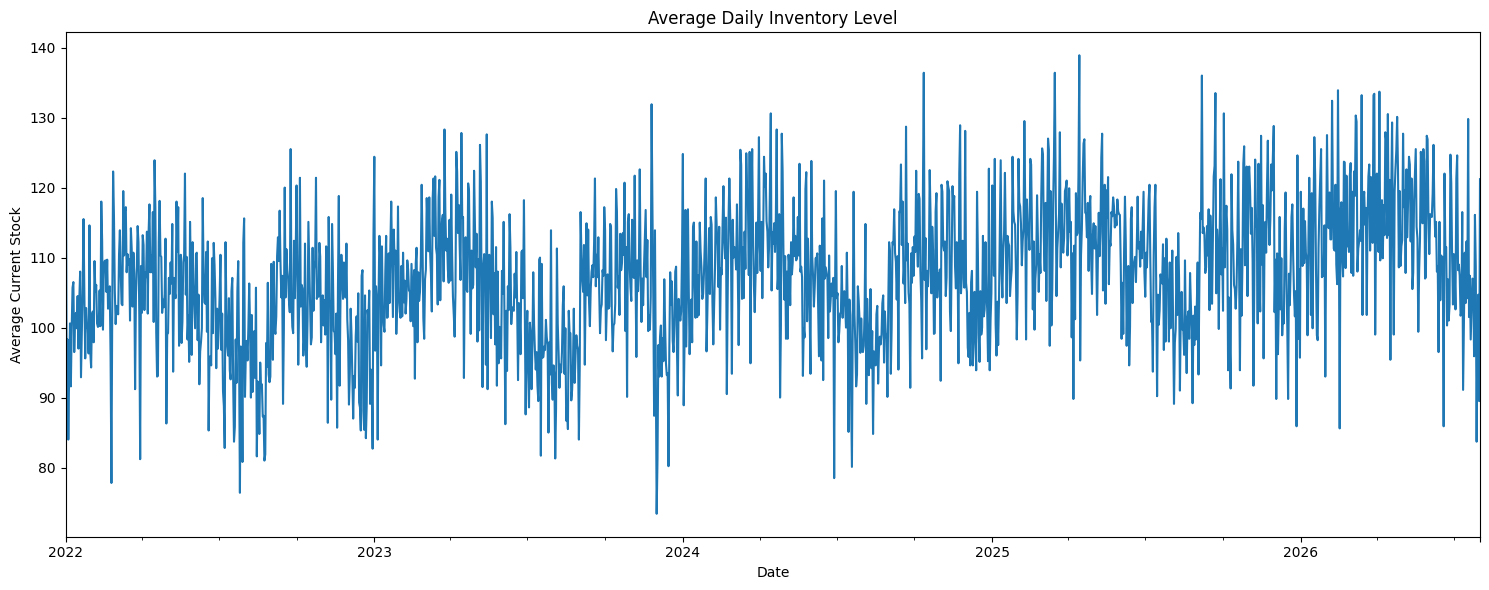

In [28]:
daily_stock = (
    df.groupby("Date")["Current_Stock"]
      .mean()
)

plt.figure(figsize=(15, 6))

daily_stock.plot()

plt.title("Average Daily Inventory Level")
plt.xlabel("Date")
plt.ylabel("Average Current Stock")

plt.tight_layout()
plt.show()

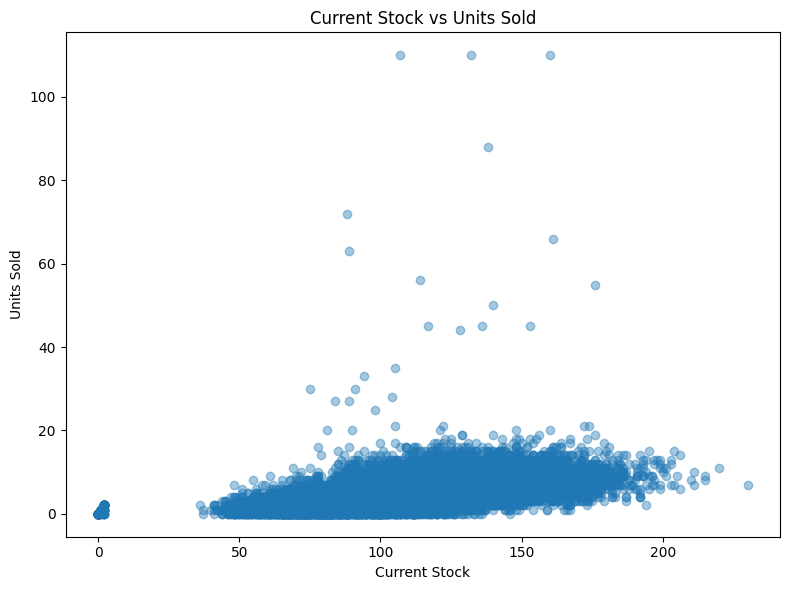

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Current_Stock"],
    df["Units_Sold"],
    alpha=0.4
)

plt.title("Current Stock vs Units Sold")
plt.xlabel("Current Stock")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

In [30]:
numeric_cols = [
    "Current_Stock",
    "Units_Sold",
    "Unit_Price",
    "Discount_Percent",
    "Promotion",
    "Holiday",
    "Lead_Time_Days",
    "Safety_Stock",
    "Stockout"
]

correlation = df[numeric_cols].corr()

correlation

,Current_Stock,Units_Sold,Unit_Price,Discount_Percent,Promotion,Holiday,Lead_Time_Days,Safety_Stock,Stockout
Current_Stock,1.000000,0.500826,-4.568462e-01,0.076907,0.022707,6.383218e-02,-6.062126e-01,6.030477e-01,-0.419133
Units_Sold,0.500826,1.000000,-5.067469e-01,0.031447,0.015646,2.676531e-02,-5.927318e-01,6.117655e-01,-0.125569
Unit_Price,-0.456846,-0.506747,1.000000e+00,-0.004110,-0.004558,-1.711249e-16,8.556709e-01,-8.518843e-01,0.006742
Discount_Percent,0.076907,0.031447,-4.109750e-03,1.000000,0.331870,-9.075568e-03,-5.159778e-03,2.511478e-03,-0.004180
Promotion,0.022707,0.015646,-4.558182e-03,0.331870,1.000000,-1.935739e-03,-7.599965e-03,2.042988e-03,0.014557
Holiday,0.063832,0.026765,-1.711249e-16,-0.009076,-0.001936,1.000000e+00,-5.586572e-17,-9.269372e-17,-0.008273
Lead_Time_Days,-0.606213,-0.592732,8.556709e-01,-0.005160,-0.007600,-5.586572e-17,1.000000e+00,-9.361697e-01,0.004580
Safety_Stock,0.603048,0.611766,-8.518843e-01,0.002511,0.002043,-9.269372e-17,-9.361697e-01,1.000000e+00,-0.006233
Stockout,-0.419133,-0.125569,6.742444e-03,-0.004180,0.014557,-8.272607e-03,4.580140e-03,-6.232884e-03,1.000000


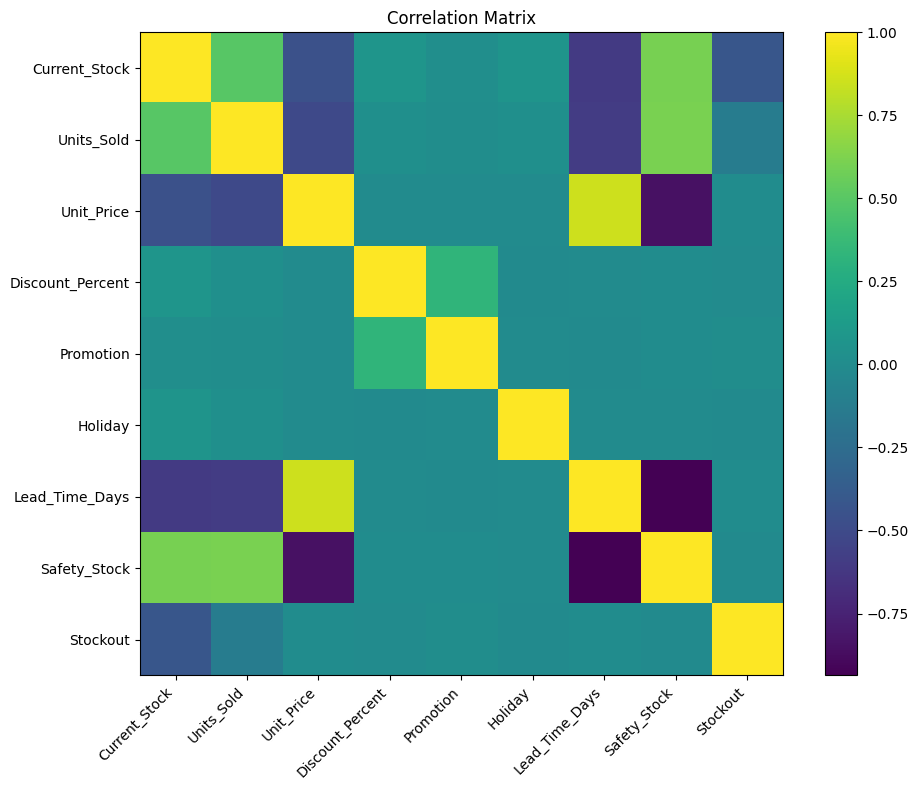

In [31]:
plt.figure(figsize=(10, 8))

plt.imshow(correlation, interpolation="nearest")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

The EDA shows that product demand changes according to product, time, promotion, holiday, stock availability, and lead time. Therefore, a fixed reorder point is not suitable. The proposed system should forecast future demand for each product and dynamically calculate its reorder point based on demand, lead time, and safety stock.